In [1]:
import os

# Check inside flowers-recognition folder
print(os.listdir('/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers'))

['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


# Part II - Vision Task: Image Classification with CNN
# Dataset: Flowers Recognition (5 Classes)


In [2]:
pip install keras tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import time
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from PIL import Image
warnings.filterwarnings('ignore')

2026-05-13 12:29:37.212248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778675377.439060      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778675377.499832      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778675378.022997      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778675378.023029      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778675378.023032      57 computation_placer.cc:177] computation placer alr

# Section 1: Data Understanding, Analysis, Visualization and Cleaning

In [4]:
# Define dataset path
base_path  = '/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers'
train_path = '/kaggle/working/flowers_split/train'
val_path   = '/kaggle/working/flowers_split/val'
test_path  = '/kaggle/working/flowers_split/test'

# Get class names from folder names
class_names = sorted(os.listdir(base_path))

print("Classes Found :", class_names)
print("Total Classes :", len(class_names))

Classes Found : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total Classes : 5


# Check for Corrupted Images

In [5]:
from PIL import Image as PILImage

corrupted_images = []
valid_images = 0

for class_name in class_names:
  class_folder = os.path.join(base_path, class_name)

  for img_file in os.listdir(class_folder):
    img_path = os.path.join(class_folder, img_file)

    try:
      img = PILImage.open(img_path)
      img.verify()
      valid_images += 1

    except Exception as e:
      corrupted_images.append(img_path)
      print(f"Corrupted image found: {img_path}")

print(f"\nTotal Valid Images           : {valid_images}")
print(f"Total Corrupted Images Found : {len(corrupted_images)}")

if len(corrupted_images) == 0:
  print("No corrupted images found! Dataset is clean.")


Total Valid Images           : 4317
Total Corrupted Images Found : 0
No corrupted images found! Dataset is clean.


# Count Total Images and Images Per Class

In [6]:
# Count total images and images per class
class_counts = {}

for class_name in class_names:
  class_folder = os.path.join(base_path, class_name)
  images = [f for f in os.listdir(class_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  class_counts[class_name] = len(images)

# Print counts
total_images = sum(class_counts.values())
print(f"Total Images in Dataset: {total_images}\n")
print("Images per Class:")
for class_name, count in class_counts.items():
  print(f"  {class_name}: {count} images")

Total Images in Dataset: 4317

Images per Class:
  daisy: 764 images
  dandelion: 1052 images
  rose: 784 images
  sunflower: 733 images
  tulip: 984 images


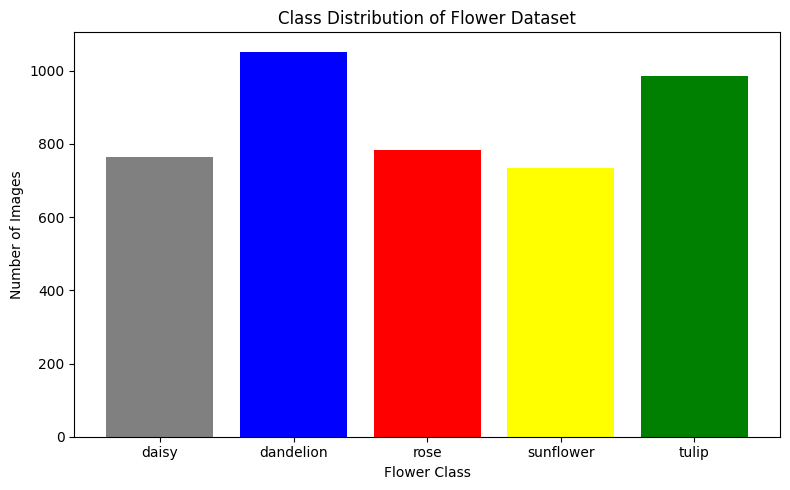

In [7]:
# Visualize class distribution as bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(),
        color=['grey', 'blue', 'red', 'yellow', 'green'])
plt.title("Class Distribution of Flower Dataset")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

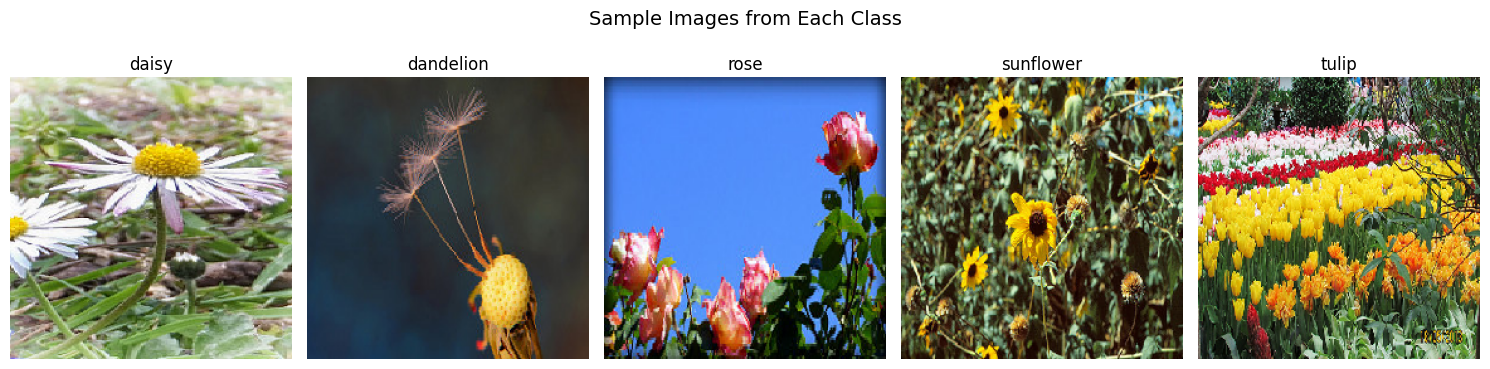

In [8]:
# Display one sample image from each class
plt.figure(figsize=(15, 4))

for i, class_name in enumerate(class_names):
  class_folder = os.path.join(base_path, class_name)
  sample_image_path = os.path.join(class_folder, os.listdir(class_folder)[0])
  img = image.load_img(sample_image_path, target_size=(224, 224))

  plt.subplot(1, len(class_names), i + 1)
  plt.imshow(img)
  plt.title(class_name)
  plt.axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

# Split Dataset into Train, Validation and Test Sets

In [9]:
# Split dataset into train (70%), val (15%) and test (15%)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

for class_name in class_names:
  class_folder = os.path.join(base_path, class_name)
  all_images = [f for f in os.listdir(class_folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

  # First split: train and temp (val + test)
  train_imgs, temp_imgs = train_test_split(
      all_images,
      test_size=(VAL_RATIO + TEST_RATIO),
      random_state=42
  )

  # Second split: val and test from temp
  val_imgs, test_imgs = train_test_split(
      temp_imgs,
      test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
      random_state=42
  )

  # Copy images to destination folders
  for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
    dest_folder = os.path.join('/kaggle/working/flowers_split', split, class_name)
    os.makedirs(dest_folder, exist_ok=True)

    for img_file in imgs:
      src = os.path.join(class_folder, img_file)
      dst = os.path.join(dest_folder, img_file)
      shutil.copy(src, dst)

print("Dataset split completed!\n")


Dataset split completed!



In [10]:
# Verify split counts for each class
print("Split Verification:\n")
print(f"{'Class':<15} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")


for class_name in class_names:
  train_count = len(os.listdir(os.path.join(train_path, class_name)))
  val_count   = len(os.listdir(os.path.join(val_path, class_name)))
  test_count  = len(os.listdir(os.path.join(test_path, class_name)))
  total       = train_count + val_count + test_count

  print(f"{class_name:<15} {train_count:>8} {val_count:>8} {test_count:>8} {total:>8}")



Split Verification:

Class              Train      Val     Test    Total
daisy                534      115      115      764
dandelion            736      158      158     1052
rose                 548      118      118      784
sunflower            513      110      110      733
tulip                688      148      148      984


# Preprocessing and Data Generators

- All images were resized to 224x224 pixels.
- Pixel values normalized to [0, 1] using rescale=1./255.
- Training data augmented to improve generalization.
- Validation and Test data only rescaled, no augmentation.

In [11]:
# Define parameters
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
NUM_CLASSES = len(class_names)

print(f"Image Size  : {IMG_SIZE}")
print(f"Batch Size  : {BATCH_SIZE}")
print(f"Num Classes : {NUM_CLASSES}")

Image Size  : (224, 224)
Batch Size  : 32
Num Classes : 5


Data Generators

In [12]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation and test generator - only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

# Load validation data
val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load test data
test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

print(f"\nTraining samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")
print(f"Test samples       : {test_generator.samples}")
print(f"Classes            : {train_generator.class_indices}")

Found 3019 images belonging to 5 classes.
Found 649 images belonging to 5 classes.
Found 649 images belonging to 5 classes.

Training samples   : 3019
Validation samples : 649
Test samples       : 649
Classes            : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


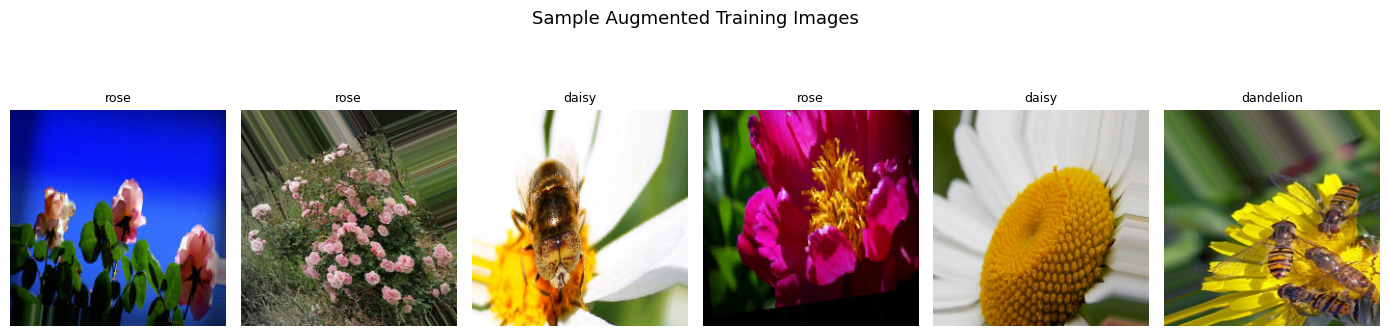

In [13]:
# Visualize sample augmented training images
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(14, 4))
for i in range(6):
  plt.subplot(1, 6, i + 1)
  plt.imshow(sample_images[i])
  plt.title(class_names[np.argmax(sample_labels[i])], fontsize=9)
  plt.axis('off')

plt.suptitle("Sample Augmented Training Images", fontsize=13)
plt.tight_layout()
plt.show()

# Observations - Section 1

* Dataset contains 4317 flower images across 5 classes.
* Classes are slightly imbalanced:
  dandelion has the most images and sunflower has the least.
* All images resized to 224x224 for consistent input to CNN.
* Dataset split into 70% train, 15% val and 15% test.
* Data augmentation applied to training data only to prevent
  overfitting and improve generalization.
* No corrupted images found in the dataset.

# Section 2 - Part A: Baseline CNN Model (From Scratch)

## Model Architecture:
- 3 Convolutional layers each followed by MaxPooling layers.
- 3 Fully Connected (Dense) layers.
- Output layer with softmax activation for 5 class classification.
- Kernel Size  : (3,3) for all Conv layers.
- Filters      : 32, 64, 128 for Conv layers respectively.
- Activation   : ReLU for all hidden layers.
- Optimizer    : Adam
- Loss         : Categorical Crossentropy

In [14]:
# Build Baseline CNN Model
baseline_model = keras.Sequential([

  # Convolutional Block 1
  layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
  layers.MaxPooling2D((2, 2)),

  # Convolutional Block 2
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),

  # Convolutional Block 3
  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers
  layers.Dense(256, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
baseline_model.compile(
    optimizer='adam',  #by default learning rate 0.001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
baseline_model.summary()

I0000 00:00:1778675513.621165      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778675513.627251      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,149 (85.01 MB)

 Trainable params: 22,286,149 (85.01 MB)

 Non-trainable params: 0 (0.00 B)

# Model Summary

- Total parameters show the complexity of the model.
- Conv layers extract spatial features from images.
- MaxPooling layers reduce spatial dimensions by half.
- Flatten layer converts 3D feature maps to 1D vector.
- Dense layers perform high level classification.
- Output layer uses softmax to predict probabilities
  for each of the 5 flower classes.

In [15]:
# Define Callbacks for training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [17]:
# Train the Baseline Model
EPOCHS = 20

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

baseline_training_time = time.time() - start_time
print(f"\nBaseline Model Training Time: {baseline_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 407ms/step - accuracy: 0.6176 - loss: 0.9757 - val_accuracy: 0.6348 - val_loss: 0.9263 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 410ms/step - accuracy: 0.6480 - loss: 0.8907 - val_accuracy: 0.7042 - val_loss: 0.8065 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 410ms/step - accuracy: 0.6638 - loss: 0.8643 - val_accuracy: 0.7227 - val_loss: 0.7448 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 400ms/step - accuracy: 0.6899 - loss: 0.8189 - val_accuracy: 0.6826 - val_loss: 0.7636 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 402ms/step - accuracy: 0.6770 - loss: 0.8095 - val_accuracy: 0.6888 - val_loss: 0.8339 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6948 - loss: 0.7777
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.6948 - loss: 0.77

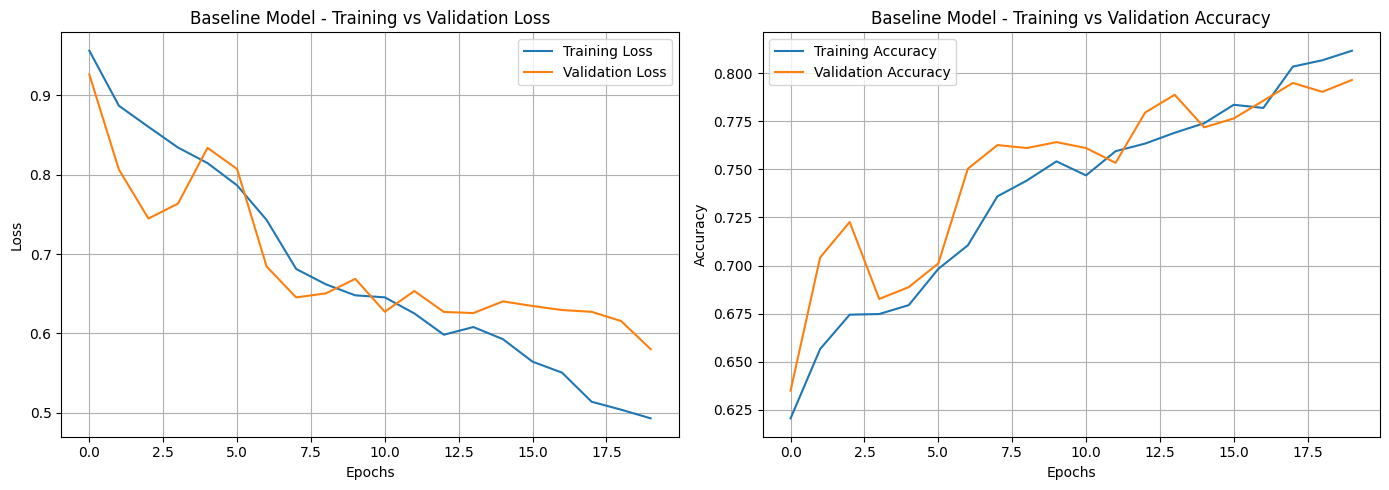

In [18]:
# Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.title("Baseline Model - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Baseline Model - Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Create evaluation generator with shuffle=False
eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Reset before predicting
eval_generator.reset()

# Predict
y_pred_probs = baseline_model.predict(eval_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - Baseline Model:")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 649 images belonging to 5 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - Baseline Model:
              precision    recall  f1-score   support

       daisy       0.87      0.72      0.79       115
   dandelion       0.84      0.88      0.86       158
        rose       0.67      0.77      0.72       118
   sunflower       0.90      0.83      0.86       110
       tulip       0.75      0.76      0.76       148

    accuracy                           0.80       649
   macro avg       0.81      0.79      0.80       649
weighted avg       0.80      0.80      0.80       649



<Figure size 800x600 with 0 Axes>

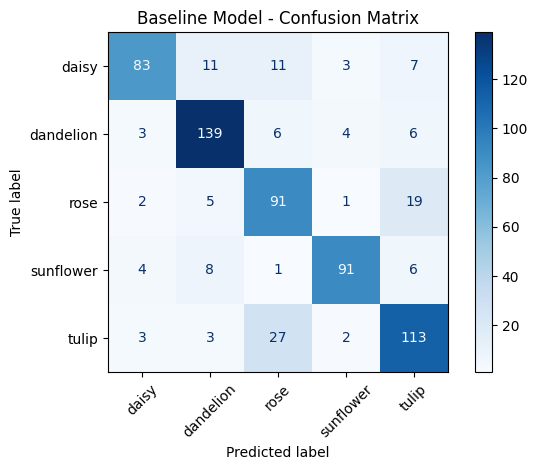

In [20]:
# Confusion Matrix - Baseline Model
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.show()

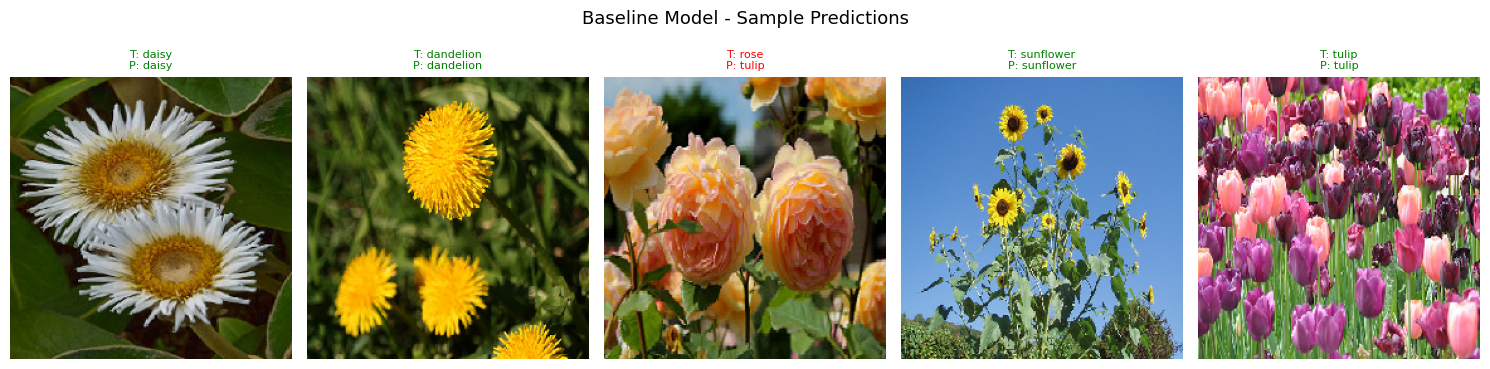

In [21]:
# Inference on sample images - one from each class
plt.figure(figsize=(15, 4))

for i, class_name in enumerate(class_names):
  # Find first image of each class from eval_generator
  class_folder = os.path.join(val_path, class_name)
  img_file = os.listdir(class_folder)[0]
  img_path = os.path.join(class_folder, img_file)

  # Load and preprocess image
  img = image.load_img(img_path, target_size=IMG_SIZE)
  img_array = image.img_to_array(img) / 255.0

  # Predict
  pred_probs = baseline_model.predict(
      img_array[np.newaxis, ...], verbose=0)
  pred_label = class_names[np.argmax(pred_probs)]
  true_label = class_name

  # Plot
  plt.subplot(1, len(class_names), i + 1)
  plt.imshow(img_array)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("Baseline Model - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# Print training summary
print(f"{'Baseline Model Summary\n'}")
print(f"Total Epochs Trained  : {len(baseline_history.history['loss'])}")
print(f"Final Training Accuracy   : {baseline_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {baseline_history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {baseline_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {baseline_history.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {baseline_training_time:.2f} seconds")


Baseline Model Summary

Total Epochs Trained  : 20
Final Training Accuracy   : 0.8119
Final Validation Accuracy : 0.7966
Final Training Loss       : 0.4930
Final Validation Loss     : 0.5801
Training Time             : 773.08 seconds


# Section 3 - Deeper CNN with Regularization

## Model Architecture:
- 8 Convolutional layers (double the baseline model of 3).
- BatchNormalization added after each Conv layer.
- Dropout layers added to reduce overfitting.
- 3 Fully Connected layers with BatchNorm and Dropout.
- Output layer with softmax activation for 5 classes.
- Kernel Size  : (3,3) for all Conv layers.
- Padding      : same (keeps spatial dimensions after Conv).
- Activation   : ReLU for all hidden layers.
- Optimizer    : Adam
- Loss         : Categorical Crossentropy

In [35]:
# Build Deeper CNN Model with BatchNorm and Dropout
deeper_model = keras.Sequential([

  # Conv Block 1
  layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                input_shape=(224, 224, 3)),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 2
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 3
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 4
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers
  layers.Dense(512, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(256, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
deeper_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 512)            │         2,04

 Total params: 27,032,741 (103.12 MB)

 Trainable params: 27,030,245 (103.11 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [36]:
# Define Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Train the Deeper Model
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

deeper_training_time = time.time() - start_time
print(f"\nDeeper Model Training Time: {deeper_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 73s 586ms/step - accuracy: 0.2918 - loss: 2.0195 - val_accuracy: 0.2435 - val_loss: 1.8167 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 419ms/step - accuracy: 0.4102 - loss: 1.5248 - val_accuracy: 0.2435 - val_loss: 2.4481 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 413ms/step - accuracy: 0.4587 - loss: 1.3340 - val_accuracy: 0.2820 - val_loss: 2.1787 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.4557 - loss: 1.3325
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - accuracy: 0.4559 - loss: 1.3319 - val_accuracy: 0.3128 - val_loss: 1.9616 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 413ms/step - accuracy: 0.5041 - loss: 1.1633 - val_accuracy: 0.3236 - val_loss: 1.7972 - learning_rate: 5.0000e-04
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - accuracy: 0.5335 - loss: 

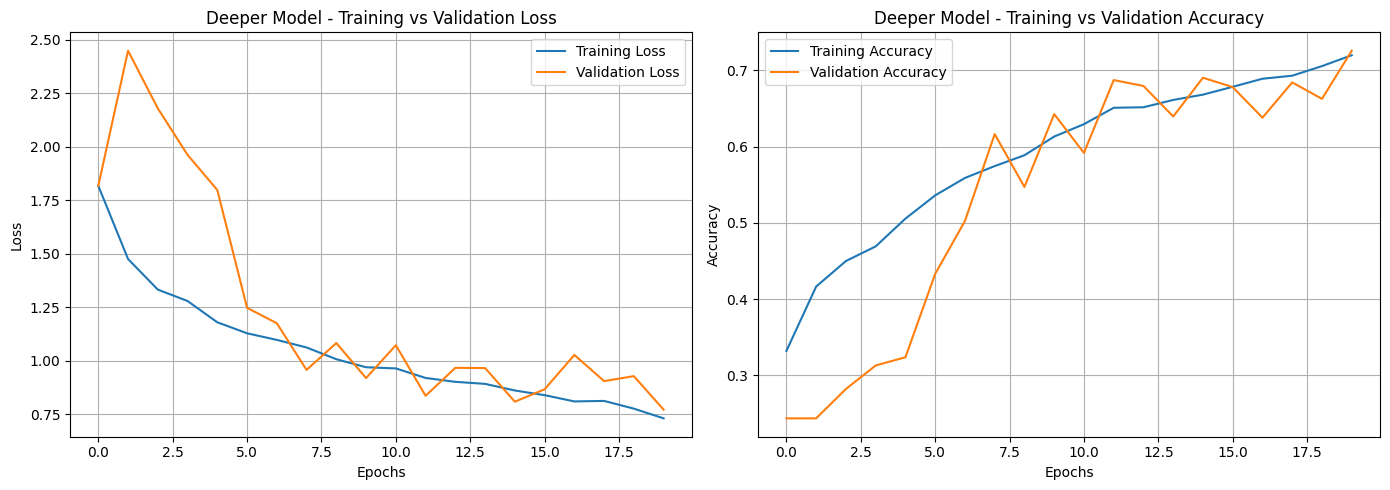

In [37]:
# Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['loss'], label='Training Loss')
plt.plot(deeper_history.history['val_loss'], label='Validation Loss')
plt.title("Deeper Model - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['accuracy'], label='Training Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Deeper Model - Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

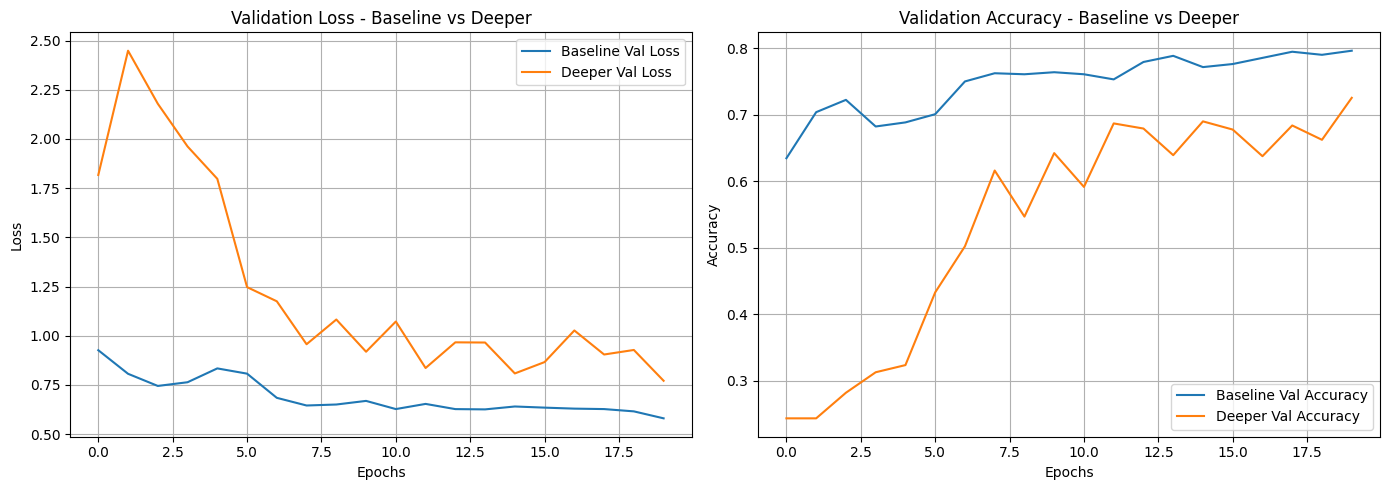

In [38]:
# Compare Baseline vs Deeper Model
plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['val_loss'], label='Baseline Val Loss')
plt.plot(deeper_history.history['val_loss'], label='Deeper Val Loss')
plt.title("Validation Loss - Baseline vs Deeper")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Deeper Val Accuracy')
plt.title("Validation Accuracy - Baseline vs Deeper")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# Evaluate Deeper Model using eval_generator
eval_generator.reset()

y_pred_deeper_probs = deeper_model.predict(eval_generator, verbose=1)
y_pred_deeper = np.argmax(y_pred_deeper_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred_deeper.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - Deeper Model:")
print(classification_report(y_true, y_pred_deeper, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - Deeper Model:
              precision    recall  f1-score   support

       daisy       0.82      0.62      0.70       115
   dandelion       0.75      0.85      0.80       158
        rose       0.59      0.75      0.66       118
   sunflower       0.70      0.84      0.76       110
       tulip       0.84      0.57      0.68       148

    accuracy                           0.73       649
   macro avg       0.74      0.73      0.72       649
weighted avg       0.74      0.73      0.72       649



<Figure size 800x600 with 0 Axes>

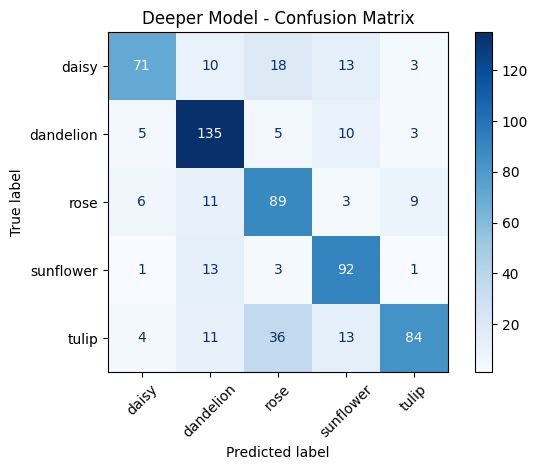

In [40]:
# Confusion Matrix - Deeper Model
cm_deeper = confusion_matrix(y_true, y_pred_deeper)
disp_deeper = ConfusionMatrixDisplay(
    confusion_matrix=cm_deeper,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp_deeper.plot(cmap='Blues', xticks_rotation=45)
plt.title("Deeper Model - Confusion Matrix")
plt.tight_layout()
plt.show()

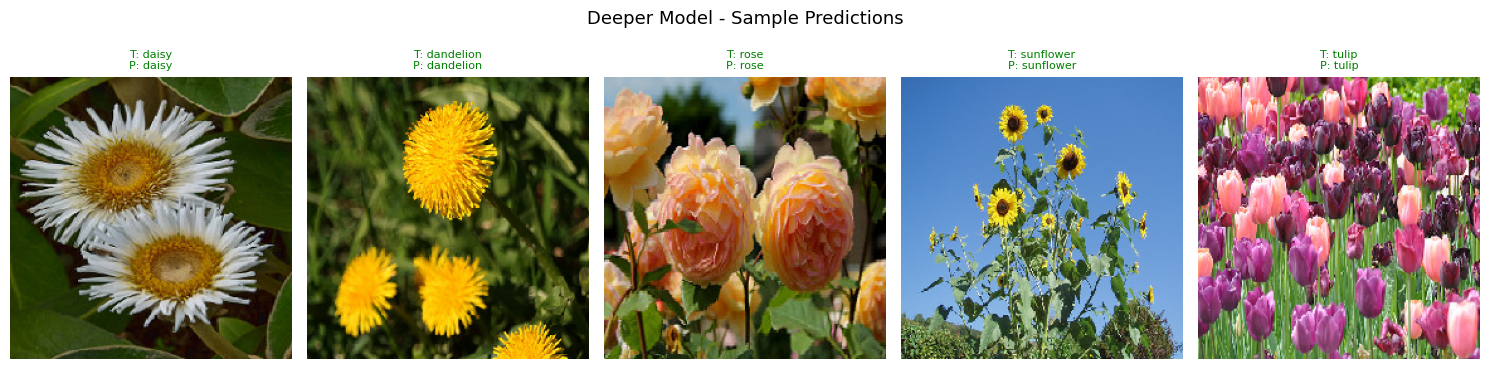

In [41]:
# Deeper Model Sample Predictions
plt.figure(figsize=(15, 4))

for i, class_name in enumerate(class_names):
  class_folder = os.path.join(val_path, class_name)
  img_file = os.listdir(class_folder)[0]
  img_path = os.path.join(class_folder, img_file)

  img = image.load_img(img_path, target_size=IMG_SIZE)
  img_array = image.img_to_array(img) / 255.0

  pred_probs = deeper_model.predict(
      img_array[np.newaxis, ...], verbose=0)
  pred_label = class_names[np.argmax(pred_probs)]
  true_label = class_name

  plt.subplot(1, len(class_names), i + 1)
  plt.imshow(img_array)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("Deeper Model - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
# Print training summary
print("=" * 55)
print(f"{'Deeper Model Summary'}")
print("=" * 55)
print(f"Total Epochs Trained      : {len(deeper_history.history['loss'])}")
print(f"Final Training Accuracy   : {deeper_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {deeper_history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {deeper_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {deeper_history.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {deeper_training_time:.2f} seconds")
print("=" * 55)

Deeper Model Summary
Total Epochs Trained      : 20
Final Training Accuracy   : 0.7198
Final Validation Accuracy : 0.7257
Final Training Loss       : 0.7304
Final Validation Loss     : 0.7710
Training Time             : 827.00 seconds


In [43]:
# Comparison Table - Baseline vs Deeper
print(f"{'Model':<25} {'Val Accuracy':>12} {'Val Loss':>10} {'Time(s)':>12}")

print(f"{'\nBaseline CNN':<25} {max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN':<25} {max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{deeper_training_time:>12.2f}")


Model                     Val Accuracy   Val Loss      Time(s)

Baseline CNN                   0.7966     0.5801       773.08
Deeper CNN                      0.7257     0.7710       827.00


# Section 4 - Experimentation and Comparative Analysis

## 4.1 Optimizer Analysis: SGD vs Adam
## 4.2 Ablation Study: Removing Dropout
## 4.3 Final Summary Table

# 4.1 Optimizer Analysis: SGD vs Adam

- Train the deeper model with SGD optimizer.
- Compare convergence speed and final performance
  against Adam optimizer.
- SGD uses fixed learning rate with momentum.
- Adam adapts learning rate for each parameter.

In [44]:
# Build Deeper Model with SGD optimizer
deeper_model_sgd = keras.Sequential([

  # Conv Block 1
  layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                input_shape=(224, 224, 3)),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 2
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 3
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 4
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers
  layers.Dense(512, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(256, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

deeper_model_sgd.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,04

 Total params: 27,032,741 (103.12 MB)

 Trainable params: 27,030,245 (103.11 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [45]:
# Compile with SGD optimizer
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled with SGD optimizer!")
print(f"Learning Rate : 0.01")
print(f"Momentum      : 0.9")

Model compiled with SGD optimizer!
Learning Rate : 0.01
Momentum      : 0.9


In [46]:
# Define Callbacks for SGD model
early_stop_sgd = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_sgd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Reset generators before training
train_generator.reset()
val_generator.reset()

# Train with SGD optimizer
start_time = time.time()

history_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop_sgd, reduce_lr_sgd],
    verbose=1
)

sgd_training_time = time.time() - start_time
print(f"\nSGD Model Training Time: {sgd_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 519ms/step - accuracy: 0.2479 - loss: 2.1893 - val_accuracy: 0.2496 - val_loss: 5.4890 - learning_rate: 0.0100
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - accuracy: 0.3565 - loss: 1.5224 - val_accuracy: 0.3467 - val_loss: 1.5146 - learning_rate: 0.0100
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 417ms/step - accuracy: 0.4147 - loss: 1.3598 - val_accuracy: 0.4206 - val_loss: 1.3312 - learning_rate: 0.0100
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 417ms/step - accuracy: 0.4331 - loss: 1.3336 - val_accuracy: 0.5100 - val_loss: 1.1501 - learning_rate: 0.0100
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 417ms/step - accuracy: 0.4458 - loss: 1.3110 - val_accuracy: 0.4884 - val_loss: 1.1816 - learning_rate: 0.0100
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 426ms/step - accuracy: 0.4780 - loss: 1.2672 - val_accuracy: 0.5347 - val_loss: 1.1307 - learning_rate: 0.0100
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - accuracy: 0.4799 - loss: 1.

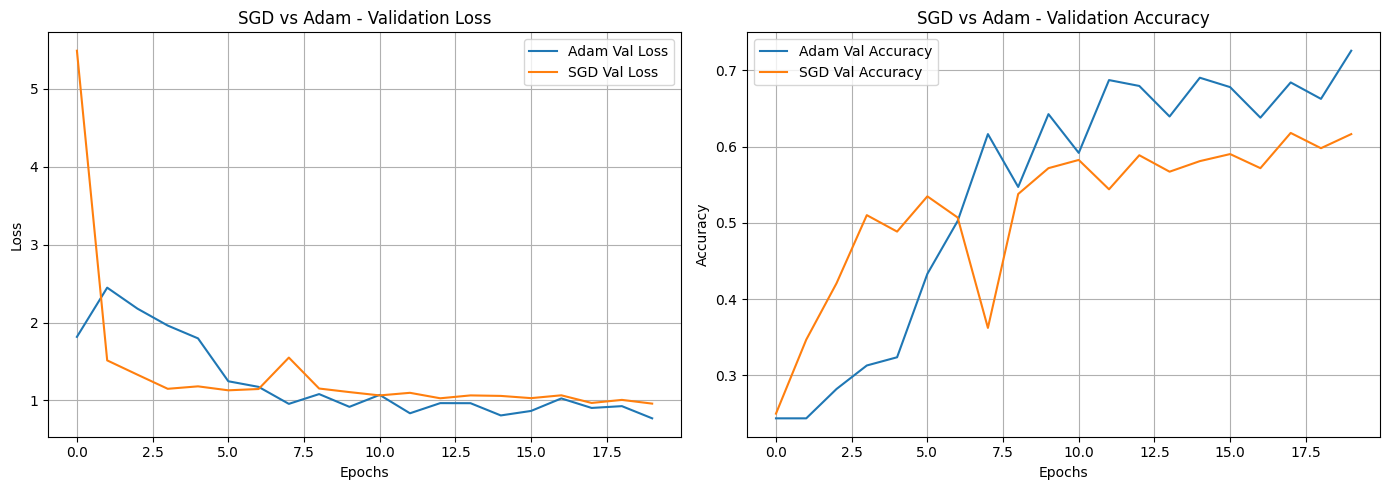

In [47]:
# Compare SGD vs Adam
plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['val_loss'], label='Adam Val Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')
plt.title("SGD vs Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['val_accuracy'], label='Adam Val Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val Accuracy')
plt.title("SGD vs Adam - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [48]:
# Evaluate SGD Model
eval_generator.reset()

y_pred_sgd_probs = deeper_model_sgd.predict(eval_generator, verbose=1)
y_pred_sgd = np.argmax(y_pred_sgd_probs, axis=1)
y_true = eval_generator.classes

print("\nClassification Report - SGD Model:")
print(classification_report(y_true, y_pred_sgd, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step

Classification Report - SGD Model:
              precision    recall  f1-score   support

       daisy       0.69      0.61      0.65       115
   dandelion       0.64      0.72      0.68       158
        rose       0.49      0.21      0.30       118
   sunflower       0.73      0.75      0.74       110
       tulip       0.53      0.74      0.61       148

    accuracy                           0.62       649
   macro avg       0.62      0.61      0.60       649
weighted avg       0.61      0.62      0.60       649



In [49]:
# SGD Model Summary
print("=" * 55)
print("SGD Model Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_sgd.history['loss'])}")
print(f"Final Training Accuracy   : {history_sgd.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_sgd.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_sgd.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_sgd.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {sgd_training_time:.2f} seconds")
print("=" * 55)

SGD Model Summary
Total Epochs Trained      : 20
Final Training Accuracy   : 0.5628
Final Validation Accuracy : 0.6163
Final Training Loss       : 1.0383
Final Validation Loss     : 0.9600
Training Time             : 814.90 seconds


# 4.2 Ablation Study: Removing Dropout

- Remove Dropout layers from the deeper model.
- Keep all other components the same (BatchNorm, same layers).
- Compare performance with and without Dropout.
- Analyze how Dropout affects overfitting and generalization.

In [50]:
# Build Deeper Model without Dropout (Ablation Study)
model_no_dropout = keras.Sequential([

  # Conv Block 1
  layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                input_shape=(224, 224, 3)),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Conv Block 2
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Conv Block 3
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Conv Block 4
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers - No Dropout!
  layers.Dense(512, activation='relu'),
  layers.BatchNormalization(),

  layers.Dense(256, activation='relu'),
  layers.BatchNormalization(),

  layers.Dense(128, activation='relu'),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

model_no_dropout.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,89

 Total params: 27,032,741 (103.12 MB)

 Trainable params: 27,030,245 (103.11 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [51]:
# Compile with Adam optimizer
model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("No Dropout Model compiled!")
print(f"Optimizer : Adam")
print(f"Loss      : Categorical Crossentropy")

No Dropout Model compiled!
Optimizer : Adam
Loss      : Categorical Crossentropy


In [52]:
# Define Callbacks for No Dropout model
early_stop_nd = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_nd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Reset generators before training
train_generator.reset()
val_generator.reset()

# Train without Dropout
start_time = time.time()

history_no_dropout = model_no_dropout.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop_nd, reduce_lr_nd],
    verbose=1
)

no_dropout_training_time = time.time() - start_time
print(f"\nNo Dropout Model Training Time: {no_dropout_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 55s 479ms/step - accuracy: 0.4395 - loss: 1.4314 - val_accuracy: 0.2435 - val_loss: 2.7858 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 421ms/step - accuracy: 0.5702 - loss: 1.1012 - val_accuracy: 0.2435 - val_loss: 4.2284 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 414ms/step - accuracy: 0.6034 - loss: 1.0196 - val_accuracy: 0.2450 - val_loss: 2.4848 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 421ms/step - accuracy: 0.5983 - loss: 0.9957 - val_accuracy: 0.3652 - val_loss: 2.0844 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 423ms/step - accuracy: 0.6460 - loss: 0.9132 - val_accuracy: 0.4622 - val_loss: 1.4141 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 416ms/step - accuracy: 0.6480 - loss: 0.8957 - val_accuracy: 0.6117 - val_loss: 1.0781 - learning_rate: 0.0010
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 420ms/step - accuracy: 0.6853 - loss: 0.

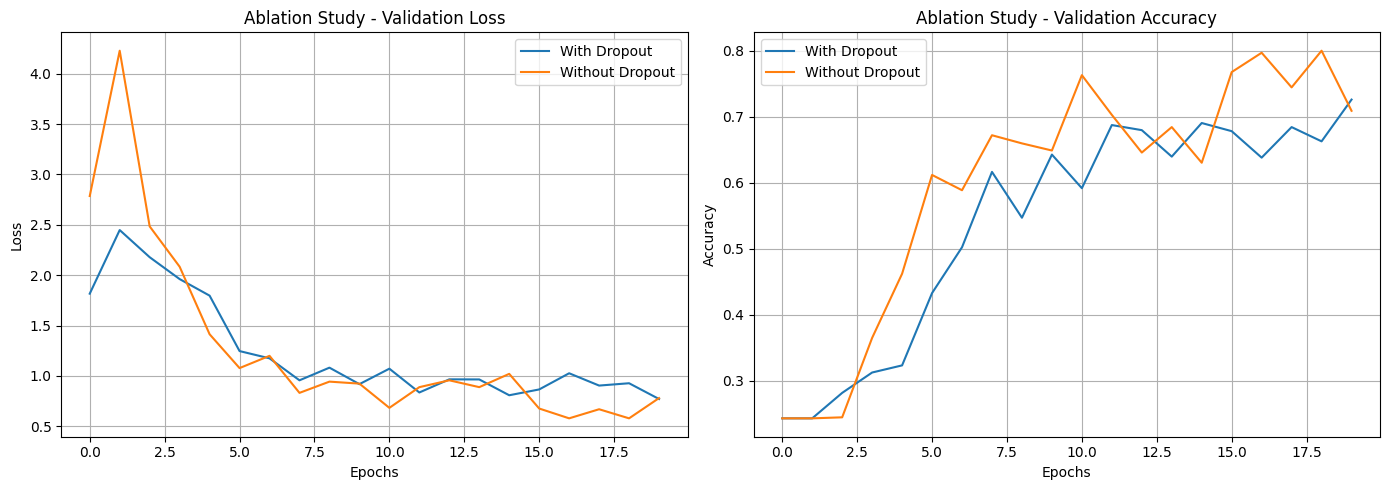

In [53]:
# Ablation Study - With vs Without Dropout
plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['val_loss'], label='With Dropout')
plt.plot(history_no_dropout.history['val_loss'], label='Without Dropout')
plt.title("Ablation Study - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['val_accuracy'], label='With Dropout')
plt.plot(history_no_dropout.history['val_accuracy'], label='Without Dropout')
plt.title("Ablation Study - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

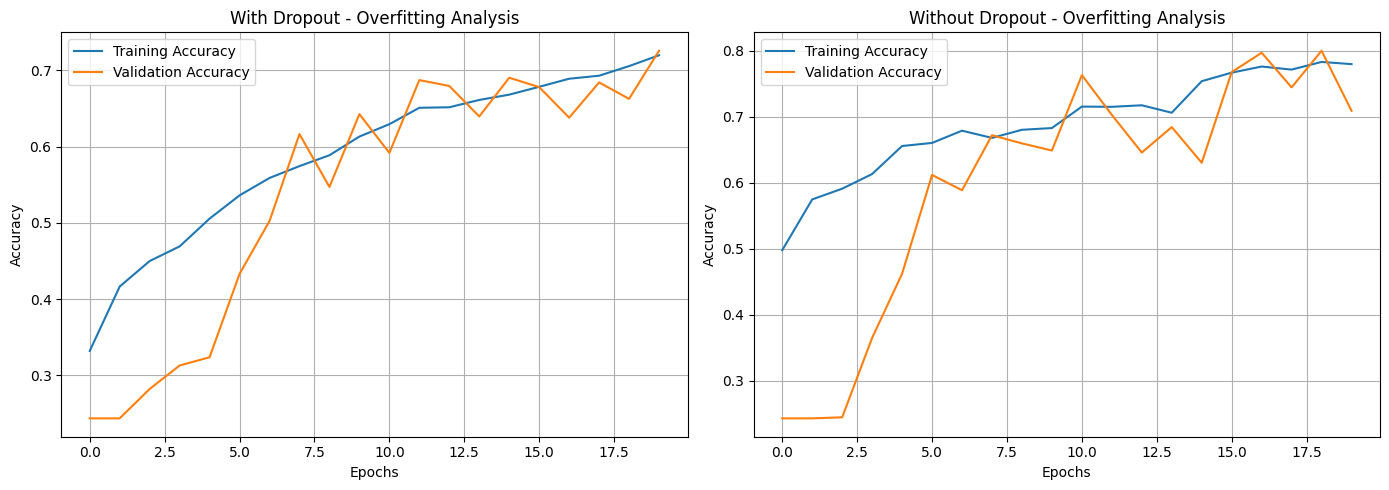

In [54]:
# Overfitting Analysis - With vs Without Dropout
plt.figure(figsize=(14, 5))

# Training vs Validation - With Dropout
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['accuracy'], label='Training Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("With Dropout - Overfitting Analysis")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Training vs Validation - Without Dropout
plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_no_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title("Without Dropout - Overfitting Analysis")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
# Evaluate No Dropout Model
eval_generator.reset()

y_pred_nd_probs = model_no_dropout.predict(eval_generator, verbose=1)
y_pred_nd = np.argmax(y_pred_nd_probs, axis=1)
y_true = eval_generator.classes

print("\nClassification Report - No Dropout Model:")
print(classification_report(y_true, y_pred_nd, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step

Classification Report - No Dropout Model:
              precision    recall  f1-score   support

       daisy       0.83      0.83      0.83       115
   dandelion       0.85      0.82      0.84       158
        rose       0.77      0.69      0.73       118
   sunflower       0.74      0.90      0.81       110
       tulip       0.79      0.76      0.78       148

    accuracy                           0.80       649
   macro avg       0.80      0.80      0.80       649
weighted avg       0.80      0.80      0.80       649



# 4.3 Summary Table

In [56]:
# Final Comparison Summary Table
print("=" * 75)
print(f"{'Model':<28} {'Val Accuracy':>12} {'Val Loss':>10} {'Epochs':>8} {'Time(s)':>12}")
print("=" * 75)
print(f"{'Baseline CNN':<28} "
      f"{max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{len(baseline_history.history['loss']):>8} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<28} "
      f"{max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{len(deeper_history.history['loss']):>8} "
      f"{deeper_training_time:>12.2f}")
print(f"{'Deeper CNN (SGD)':<28} "
      f"{max(history_sgd.history['val_accuracy']):>12.4f} "
      f"{min(history_sgd.history['val_loss']):>10.4f} "
      f"{len(history_sgd.history['loss']):>8} "
      f"{sgd_training_time:>12.2f}")
print(f"{'Deeper CNN (No Dropout)':<28} "
      f"{max(history_no_dropout.history['val_accuracy']):>12.4f} "
      f"{min(history_no_dropout.history['val_loss']):>10.4f} "
      f"{len(history_no_dropout.history['loss']):>8} "
      f"{no_dropout_training_time:>12.2f}")
print("=" * 75)

Model                        Val Accuracy   Val Loss   Epochs      Time(s)
Baseline CNN                       0.7966     0.5801       20       773.08
Deeper CNN (Adam)                  0.7257     0.7710       20       827.00
Deeper CNN (SGD)                   0.6179     0.9600       20       814.90
Deeper CNN (No Dropout)            0.7997     0.5792       20       810.44


In [57]:
# Save all models
baseline_model.save('/kaggle/working/baseline_cnn_flowers.h5')
print("Baseline model saved!")

deeper_model.save('/kaggle/working/deeper_cnn_flowers.h5')
print("Deeper model saved!")

deeper_model_sgd.save('/kaggle/working/deeper_cnn_sgd_flowers.h5')
print("SGD model saved!")

model_no_dropout.save('/kaggle/working/deeper_cnn_no_dropout_flowers.h5')
print("No Dropout model saved!")

Baseline model saved!


Deeper model saved!


SGD model saved!
No Dropout model saved!


# Section 5 - Part B: Transfer Learning
# Model: MobileNetV2
# Strategy: Feature Extraction → Fine Tuning

## Why MobileNetV2?
- Lightweight and efficient architecture.
- Designed to work well on small datasets.
- Pretrained on ImageNet (14 million images, 1000 classes).
- Accepts 224x224 input which matches our dataset.
- Widely used in real world mobile applications.

## Strategy:
- Phase 1 - Feature Extraction:
  → Freeze all MobileNetV2 base layers.
  → Train only newly added Dense layers.
  → Learn task specific features first.

- Phase 2 - Fine Tuning:
  → Unfreeze top layers of Mobil

In [58]:
# Load MobileNetV2 pretrained on ImageNet
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # Remove original classification head
    weights='imagenet'       # Use pretrained ImageNet weights
)

print(f"Base Model     : MobileNetV2")
print(f"Input Shape    : (224, 224, 3)")
print(f"Weights        : ImageNet")
print(f"Total Layers   : {len(base_model.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model     : MobileNetV2
Input Shape    : (224, 224, 3)
Weights        : ImageNet
Total Layers   : 154


In [59]:
# Freeze all layers in base model
base_model.trainable = False

# Verify frozen layers
frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)
print(f"Total Layers in Base Model : {len(base_model.layers)}")
print(f"Frozen Layers              : {frozen_layers}")
print(f"Trainable Layers           : {len(base_model.layers) - frozen_layers}")

Total Layers in Base Model : 154
Frozen Layers              : 154
Trainable Layers           : 0


In [60]:
# Build Transfer Learning Model - Phase 1 (Feature Extraction)
inputs = keras.Input(shape=(224, 224, 3))

# Base model - frozen
x = base_model(inputs, training=False)

# Add new classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# Output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
mobilenet_model = keras.Model(inputs, outputs)

# Compile
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,485 (10.00 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

# Phase 1: Feature Extraction
- All MobileNetV2 base layers are frozen.
- Only newly added Dense layers are trained.
- Model learns task specific features for flower classification.
- Higher learning rate used as only new layers are trained.

In [61]:
# Define Callbacks for Phase 1
early_stop_p1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_p1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Phase 1 Callbacks defined!")
print(f"Early Stopping patience : 5 epochs")
print(f"Reduce LR factor        : 0.5")

Phase 1 Callbacks defined!
Early Stopping patience : 5 epochs
Reduce LR factor        : 0.5


In [62]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [63]:
# Phase 1 Training - Feature Extraction
EPOCHS_P1 = 10

start_time = time.time()

history_p1 = mobilenet_model.fit(
    train_generator,
    epochs=EPOCHS_P1,
    validation_data=val_generator,
    callbacks=[early_stop_p1, reduce_lr_p1],
    verbose=1
)

p1_training_time = time.time() - start_time
print(f"\nPhase 1 Training Time: {p1_training_time:.2f} seconds")

Epoch 1/10


2026-05-13 13:53:59.085602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 13:53:59.221906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


21/95 ━━━━━━━━━━━━━━━━━━━━ 27s 369ms/step - accuracy: 0.4684 - loss: 1.5134

2026-05-13 13:54:19.244561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 13:54:19.382160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.6413 - loss: 1.0063

2026-05-13 13:55:05.249361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 13:55:05.391660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 694ms/step - accuracy: 0.6422 - loss: 1.0036 - val_accuracy: 0.8598 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.8187 - loss: 0.5005 - val_accuracy: 0.8706 - val_loss: 0.3940 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 397ms/step - accuracy: 0.8494 - loss: 0.4205 - val_accuracy: 0.8752 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.8466 - loss: 0.4049 - val_accuracy: 0.8752 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 401ms/step - accuracy: 0.8718 - loss: 0.3504 - val_accuracy: 0.8690 - val_loss: 0.3744 - learning_rate: 0.0010
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 409ms/step - accuracy: 0.8928 - loss: 0.2952 - val_accuracy: 0.8829 - val_loss: 0.3846 - learning_rate: 0.0010
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8818 - loss: 0.3231
Epoch 7

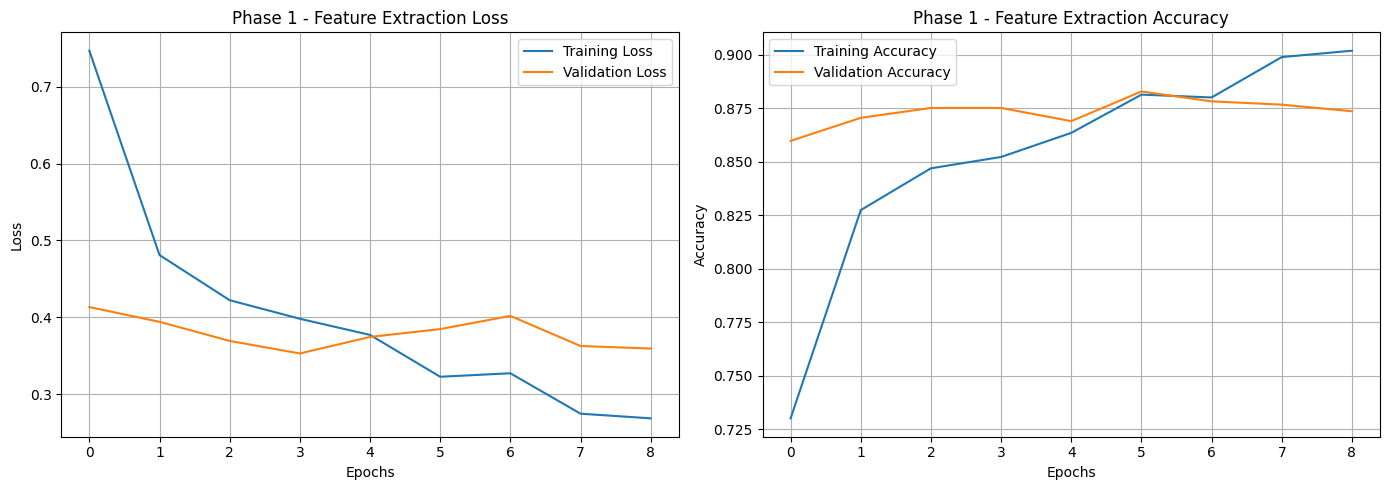

In [64]:
# Plot Phase 1 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_p1.history['loss'], label='Training Loss')
plt.plot(history_p1.history['val_loss'], label='Validation Loss')
plt.title("Phase 1 - Feature Extraction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_p1.history['accuracy'], label='Training Accuracy')
plt.plot(history_p1.history['val_accuracy'], label='Validation Accuracy')
plt.title("Phase 1 - Feature Extraction Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [65]:
# Phase 1 Summary
print("=" * 55)
print("Phase 1 - Feature Extraction Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_p1.history['loss'])}")
print(f"Final Training Accuracy   : {history_p1.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_p1.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_p1.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_p1.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {p1_training_time:.2f} seconds")
print("=" * 55)

Phase 1 - Feature Extraction Summary
Total Epochs Trained      : 9
Final Training Accuracy   : 0.9020
Final Validation Accuracy : 0.8737
Final Training Loss       : 0.2684
Final Validation Loss     : 0.3593
Training Time             : 392.92 seconds


# Phase 2: Fine Tuning
- Unfreeze top 30 layers of MobileNetV2 base model.
- Train with very low learning rate (0.0001) to avoid
  catastrophic forgetting of pretrained weights.
- Allow model to adapt pretrained features to flower dataset.
- Fine tuning improves accuracy by adjusting high level
  features learned from ImageNet to flower specific features.

In [66]:
# Unfreeze top 30 layers of base model for fine tuning
base_model.trainable = True

# Freeze all layers except top 30
for layer in base_model.layers[:-30]:
  layer.trainable = False

# Count trainable layers
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)

print(f"Total Layers in Base Model : {len(base_model.layers)}")
print(f"Frozen Layers              : {frozen_layers}")
print(f"Trainable Layers           : {trainable_layers}")
print(f"\nFine tuning top {trainable_layers} layers!")

Total Layers in Base Model : 154
Frozen Layers              : 124
Trainable Layers           : 30

Fine tuning top 30 layers!


In [67]:
# Recompile with lower learning rate for fine tuning
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for Fine Tuning!")
print(f"New Learning Rate : 0.0001")

Model recompiled for Fine Tuning!
New Learning Rate : 0.0001


In [68]:
# Define Callbacks for Phase 2
early_stop_p2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_p2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

print("Phase 2 Callbacks defined!")

Phase 2 Callbacks defined!


In [69]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [70]:
# Phase 2 Training - Fine Tuning
EPOCHS_P2 = 10

start_time = time.time()

history_p2 = mobilenet_model.fit(
    train_generator,
    epochs=EPOCHS_P2,
    validation_data=val_generator,
    callbacks=[early_stop_p2, reduce_lr_p2],
    verbose=1
)

p2_training_time = time.time() - start_time
print(f"\nPhase 2 Training Time: {p2_training_time:.2f} seconds")

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 72s 567ms/step - accuracy: 0.8301 - loss: 0.4471 - val_accuracy: 0.8891 - val_loss: 0.3711 - learning_rate: 1.0000e-04
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 401ms/step - accuracy: 0.8850 - loss: 0.3205 - val_accuracy: 0.8998 - val_loss: 0.3125 - learning_rate: 1.0000e-04
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 400ms/step - accuracy: 0.9096 - loss: 0.2713 - val_accuracy: 0.8844 - val_loss: 0.3622 - learning_rate: 1.0000e-04
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 407ms/step - accuracy: 0.9265 - loss: 0.1996 - val_accuracy: 0.8937 - val_loss: 0.3570 - learning_rate: 1.0000e-04
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9334 - loss: 0.1937
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 397ms/step - accuracy: 0.9334 - loss: 0.1937 - val_accuracy: 0.9091 - val_loss: 0.3161 - learning_rate: 1.0000e-04
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 400ms/step - accuracy:

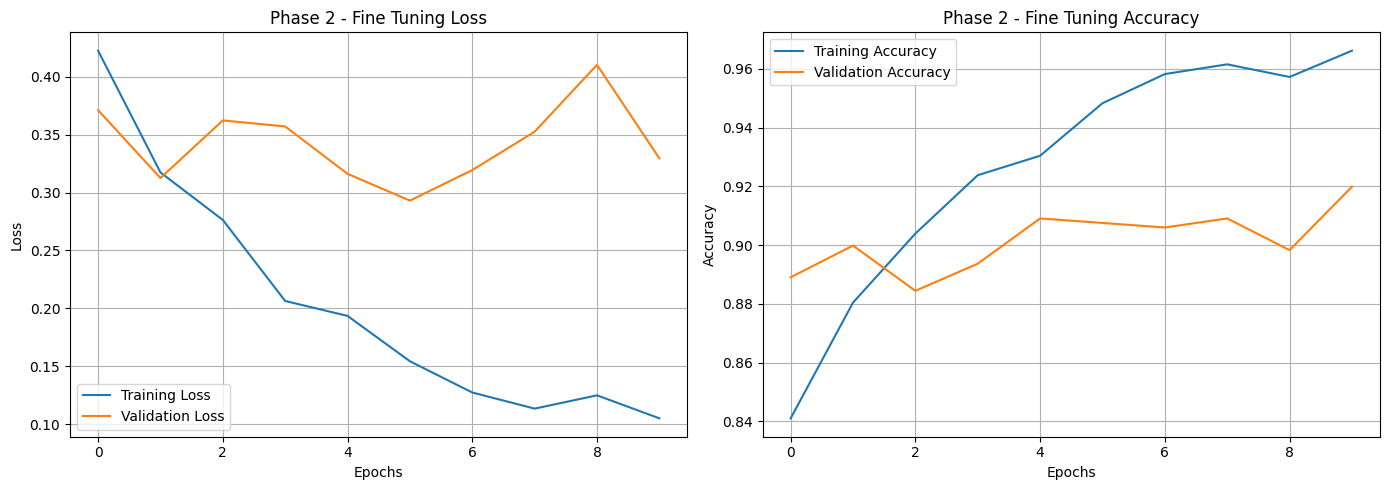

In [71]:
# Plot Phase 2 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_p2.history['loss'], label='Training Loss')
plt.plot(history_p2.history['val_loss'], label='Validation Loss')
plt.title("Phase 2 - Fine Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_p2.history['accuracy'], label='Training Accuracy')
plt.plot(history_p2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Phase 2 - Fine Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

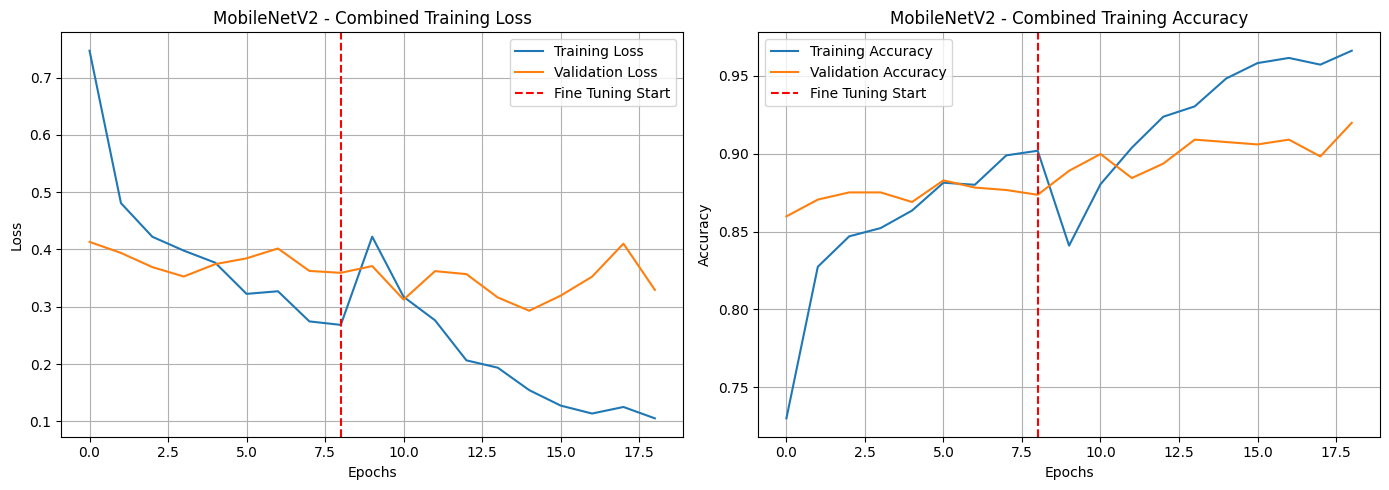

In [72]:
# Plot Combined Phase 1 and Phase 2 Training History
acc     = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss    = history_p1.history['loss']         + history_p2.history['loss']
val_loss= history_p1.history['val_loss']     + history_p2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Combined Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=len(history_p1.history['loss']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 - Combined Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Combined Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history_p1.history['accuracy']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 - Combined Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [73]:
# Evaluate MobileNetV2 on validation set
eval_generator.reset()

y_pred_mobile_probs = mobilenet_model.predict(eval_generator, verbose=1)
y_pred_mobile = np.argmax(y_pred_mobile_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred_mobile.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - MobileNetV2:")
print(classification_report(y_true, y_pred_mobile, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 292ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - MobileNetV2:
              precision    recall  f1-score   support

       daisy       0.94      0.90      0.92       115
   dandelion       0.94      0.95      0.94       158
        rose       0.91      0.86      0.88       118
   sunflower       0.81      0.95      0.88       110
       tulip       0.93      0.87      0.90       148

    accuracy                           0.91       649
   macro avg       0.91      0.91      0.91       649
weighted avg       0.91      0.91      0.91       649



<Figure size 800x600 with 0 Axes>

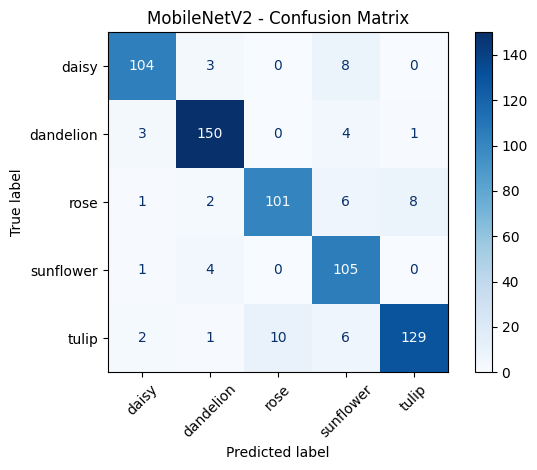

In [74]:
# Confusion Matrix - MobileNetV2
cm_mobile = confusion_matrix(y_true, y_pred_mobile)
disp_mobile = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp_mobile.plot(cmap='Blues', xticks_rotation=45)
plt.title("MobileNetV2 - Confusion Matrix")
plt.tight_layout()
plt.show()

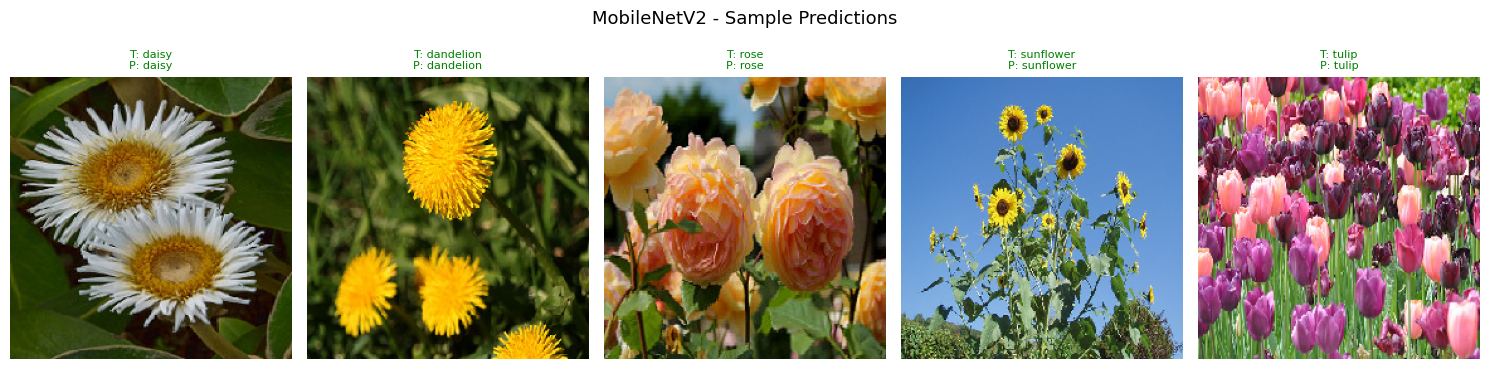

In [76]:
# MobileNetV2 Sample Predictions
plt.figure(figsize=(15, 4))

for i, class_name in enumerate(class_names):
  class_folder = os.path.join(val_path, class_name)
  img_file = os.listdir(class_folder)[0]
  img_path = os.path.join(class_folder, img_file)

  img = image.load_img(img_path, target_size=IMG_SIZE)
  img_array = image.img_to_array(img) / 255.0

  pred_probs = mobilenet_model.predict(
      img_array[np.newaxis, ...], verbose=0)
  pred_label = class_names[np.argmax(pred_probs)]
  true_label = class_name

  plt.subplot(1, len(class_names), i + 1)
  plt.imshow(img_array)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("MobileNetV2 - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [78]:
# Phase 2 Summary
print("=" * 55)
print("Phase 2 - Fine Tuning Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_p2.history['loss'])}")
print(f"Final Training Accuracy   : {history_p2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_p2.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_p2.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_p2.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {p2_training_time:.2f} seconds")
print("=" * 55)

Phase 2 - Fine Tuning Summary
Total Epochs Trained      : 10
Final Training Accuracy   : 0.9662
Final Validation Accuracy : 0.9199
Final Training Loss       : 0.1052
Final Validation Loss     : 0.3295
Training Time             : 415.26 seconds


In [77]:
# Save MobileNetV2 model
mobilenet_model.save('/kaggle/working/mobilenetv2_flowers.h5')
print("MobileNetV2 model saved!")

MobileNetV2 model saved!


In [ ]:
# Final Complete Comparison - All Models
print("=" * 75)
print(f"{'Model':<28} {'Val Accuracy':>12} {'Val Loss':>10} {'Time(s)':>12}")
print("=" * 75)
print(f"{'Baseline CNN':<28} "
      f"{max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<28} "
      f"{max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{deeper_training_time:>12.2f}")
print(f"{'Deeper CNN (SGD)':<28} "
      f"{max(history_sgd.history['val_accuracy']):>12.4f} "
      f"{min(history_sgd.history['val_loss']):>10.4f} "
      f"{sgd_training_time:>12.2f}")
print(f"{'Deeper CNN (No Dropout)':<28} "
      f"{max(history_no_dropout.history['val_accuracy']):>12.4f} "
      f"{min(history_no_dropout.history['val_loss']):>10.4f} "
      f"{no_dropout_training_time:>12.2f}")
print(f"{'MobileNetV2 (Transfer)':<28} "
      f"{max(max(history_p1.history['val_accuracy']), max(history_p2.history['val_accuracy'])):>12.4f} "
      f"{min(min(history_p1.history['val_loss']), min(history_p2.history['val_loss'])):>10.4f} "
      f"{p1_training_time + p2_training_time:>12.2f}")
print("=" * 75)

In [ ]:
# Save MobileNetV2 final model
mobilenet_model.save('/kaggle/working/mobilenetv2_flowers_final.h5')
print("Final MobileNetV2 model saved!")
print("Location: /kaggle/working/mobilenetv2_flowers_final.h5")

# Section 5 - Part B: Transfer Learning
# Model: VGG16
# Strategy: Feature Extraction → Fine Tuning



In [79]:
# Load VGG16 pretrained on ImageNet
vgg_base = keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,       # Remove original classification head
    weights='imagenet'       # Use pretrained ImageNet weights
)

print(f"Base Model     : VGG16")
print(f"Input Shape    : (224, 224, 3)")
print(f"Weights        : ImageNet")
print(f"Total Layers   : {len(vgg_base.layers)}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base Model     : VGG16
Input Shape    : (224, 224, 3)
Weights        : ImageNet
Total Layers   : 19


In [80]:
# Freeze all layers in VGG16 base
vgg_base.trainable = False

# Verify frozen layers
frozen_layers = sum(1 for layer in vgg_base.layers if not layer.trainable)
print(f"Total Layers in VGG16      : {len(vgg_base.layers)}")
print(f"Frozen Layers              : {frozen_layers}")
print(f"Trainable Layers           : {len(vgg_base.layers) - frozen_layers}")

Total Layers in VGG16      : 19
Frozen Layers              : 19
Trainable Layers           : 0


In [81]:
# Build VGG16 Transfer Learning Model - Phase 1
inputs = keras.Input(shape=(224, 224, 3))

# VGG16 base - frozen
x = vgg_base(inputs, training=False)

# Add new classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# Output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
vgg_model = keras.Model(inputs, outputs)

# Compile
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,581 (56.76 MB)

 Trainable params: 165,381 (646.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

# Phase 1: Feature Extraction - VGG16
- All VGG16 base layers are frozen.
- Only newly added Dense layers are trained.
- Model learns task specific features for flower classification.
- Higher learning rate used as only new layers are trained.

In [82]:
# Define Callbacks for VGG16 Phase 1
early_stop_vgg_p1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg_p1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("VGG16 Phase 1 Callbacks defined!")
print(f"Early Stopping patience : 5 epochs")
print(f"Reduce LR factor        : 0.5")

VGG16 Phase 1 Callbacks defined!
Early Stopping patience : 5 epochs
Reduce LR factor        : 0.5


In [83]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [84]:
# VGG16 Phase 1 Training - Feature Extraction
EPOCHS_VGG_P1 = 10

start_time = time.time()

history_vgg_p1 = vgg_model.fit(
    train_generator,
    epochs=EPOCHS_VGG_P1,
    validation_data=val_generator,
    callbacks=[early_stop_vgg_p1, reduce_lr_vgg_p1],
    verbose=1
)

vgg_p1_training_time = time.time() - start_time
print(f"\nVGG16 Phase 1 Training Time: {vgg_p1_training_time:.2f} seconds")

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 68s 568ms/step - accuracy: 0.4980 - loss: 1.2566 - val_accuracy: 0.6117 - val_loss: 1.2021 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 449ms/step - accuracy: 0.7339 - loss: 0.7223 - val_accuracy: 0.7627 - val_loss: 0.8523 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 447ms/step - accuracy: 0.7520 - loss: 0.6757 - val_accuracy: 0.7411 - val_loss: 0.7199 - learning_rate: 0.0010
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 437ms/step - accuracy: 0.7764 - loss: 0.5963 - val_accuracy: 0.7935 - val_loss: 0.5541 - learning_rate: 0.0010
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.7809 - loss: 0.5655 - val_accuracy: 0.8166 - val_loss: 0.5005 - learning_rate: 0.0010
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step - accuracy: 0.8069 - loss: 0.5318 - val_accuracy: 0.8290 - val_loss: 0.4726 - learning_rate: 0.0010
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 443ms/step - accuracy: 0.7951 - loss: 0.

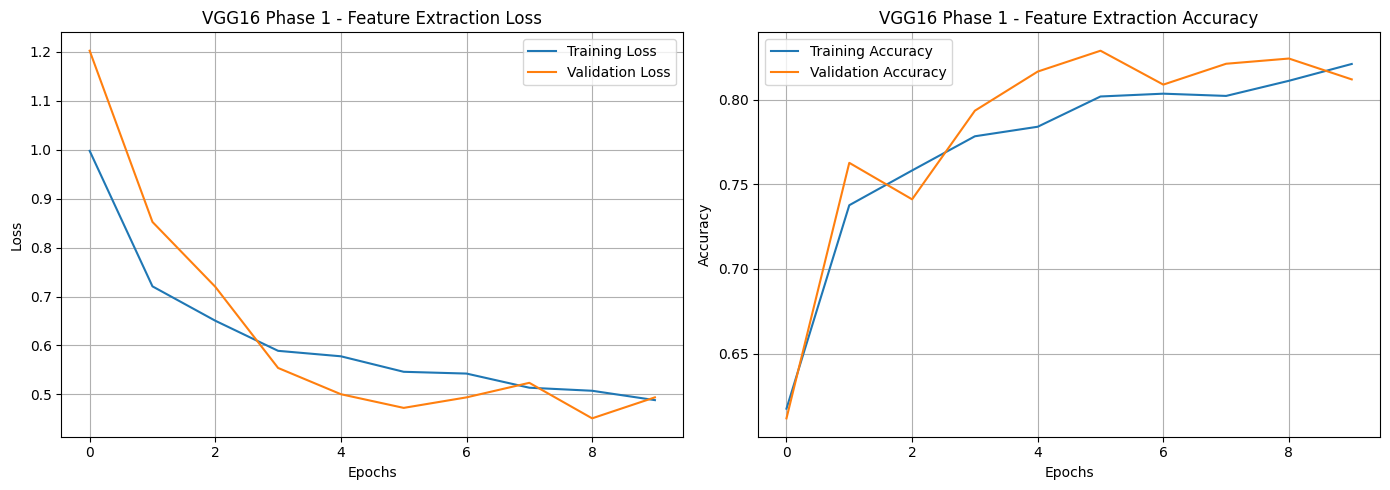

In [86]:
# Plot VGG16 Phase 1 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_vgg_p1.history['loss'], label='Training Loss')
plt.plot(history_vgg_p1.history['val_loss'], label='Validation Loss')
plt.title("VGG16 Phase 1 - Feature Extraction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_vgg_p1.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg_p1.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG16 Phase 1 - Feature Extraction Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [87]:
# VGG16 Phase 1 Summary
print("=" * 55)
print("VGG16 Phase 1 - Feature Extraction Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_vgg_p1.history['loss'])}")
print(f"Final Training Accuracy   : {history_vgg_p1.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_vgg_p1.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_vgg_p1.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_vgg_p1.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {vgg_p1_training_time:.2f} seconds")
print("=" * 55)

VGG16 Phase 1 - Feature Extraction Summary
Total Epochs Trained      : 10
Final Training Accuracy   : 0.8211
Final Validation Accuracy : 0.8120
Final Training Loss       : 0.4884
Final Validation Loss     : 0.4941
Training Time             : 450.00 seconds


# Phase 2: Fine Tuning - VGG16
- Unfreeze top 4 layers of VGG16 base model.
- VGG16 has fewer layers than MobileNetV2 so we
  unfreeze fewer layers to avoid catastrophic forgetting.
- Train with very low learning rate (0.0001).
- Allow model to adapt pretrained features to flowers.

In [88]:
# Unfreeze top 4 layers of VGG16 for fine tuning
vgg_base.trainable = True

# Freeze all layers except top 4
for layer in vgg_base.layers[:-4]:
  layer.trainable = False

# Count trainable layers
trainable_layers = sum(1 for layer in vgg_base.layers if layer.trainable)
frozen_layers    = sum(1 for layer in vgg_base.layers if not layer.trainable)

print(f"Total Layers in VGG16 : {len(vgg_base.layers)}")
print(f"Frozen Layers         : {frozen_layers}")
print(f"Trainable Layers      : {trainable_layers}")
print(f"\nFine tuning top {trainable_layers} layers!")

Total Layers in VGG16 : 19
Frozen Layers         : 15
Trainable Layers      : 4

Fine tuning top 4 layers!


In [89]:
# Recompile with lower learning rate for fine tuning
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 recompiled for Fine Tuning!")
print(f"New Learning Rate : 0.0001")

VGG16 recompiled for Fine Tuning!
New Learning Rate : 0.0001


In [90]:
# Define Callbacks for VGG16 Phase 2
early_stop_vgg_p2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg_p2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

print("VGG16 Phase 2 Callbacks defined!")

VGG16 Phase 2 Callbacks defined!


In [91]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [92]:
# VGG16 Phase 2 Training - Fine Tuning
EPOCHS_VGG_P2 = 10

start_time = time.time()

history_vgg_p2 = vgg_model.fit(
    train_generator,
    epochs=EPOCHS_VGG_P2,
    validation_data=val_generator,
    callbacks=[early_stop_vgg_p2, reduce_lr_vgg_p2],
    verbose=1
)

vgg_p2_training_time = time.time() - start_time
print(f"\nVGG16 Phase 2 Training Time: {vgg_p2_training_time:.2f} seconds")

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 53s 482ms/step - accuracy: 0.7617 - loss: 0.6994 - val_accuracy: 0.8428 - val_loss: 0.4240 - learning_rate: 1.0000e-04
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 446ms/step - accuracy: 0.8506 - loss: 0.4067 - val_accuracy: 0.8690 - val_loss: 0.3626 - learning_rate: 1.0000e-04
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 441ms/step - accuracy: 0.8788 - loss: 0.3291 - val_accuracy: 0.8721 - val_loss: 0.3758 - learning_rate: 1.0000e-04
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 446ms/step - accuracy: 0.8901 - loss: 0.3116 - val_accuracy: 0.7042 - val_loss: 1.1049 - learning_rate: 1.0000e-04
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8846 - loss: 0.3217
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 438ms/step - accuracy: 0.8847 - loss: 0.3214 - val_accuracy: 0.8582 - val_loss: 0.4196 - learning_rate: 1.0000e-04
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 449ms/step - accuracy:

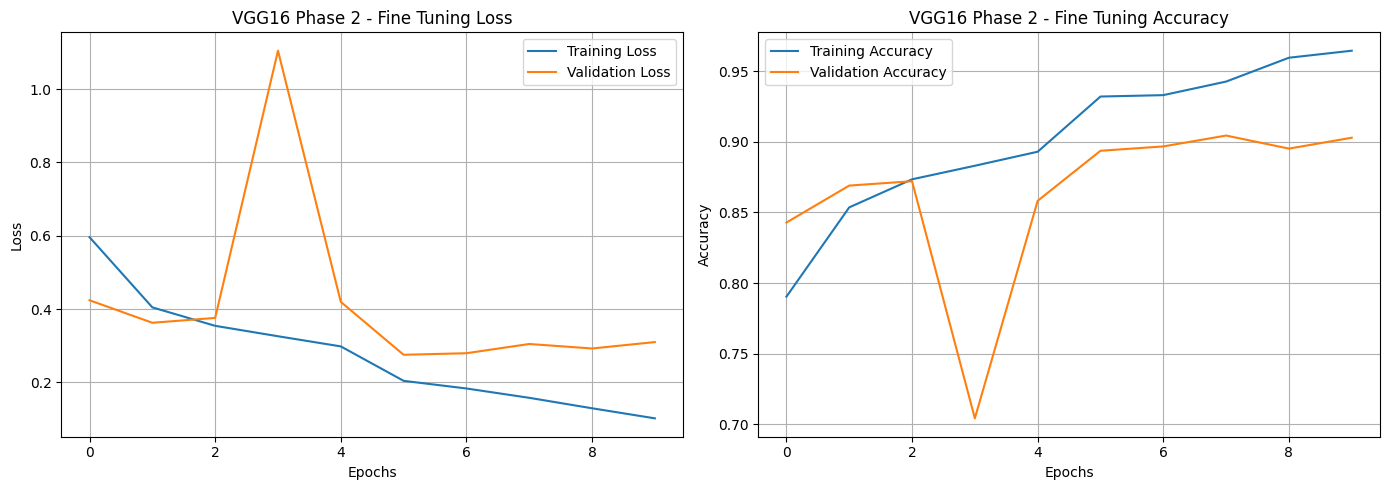

In [93]:
# Plot VGG16 Phase 2 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_vgg_p2.history['loss'], label='Training Loss')
plt.plot(history_vgg_p2.history['val_loss'], label='Validation Loss')
plt.title("VGG16 Phase 2 - Fine Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_vgg_p2.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg_p2.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG16 Phase 2 - Fine Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

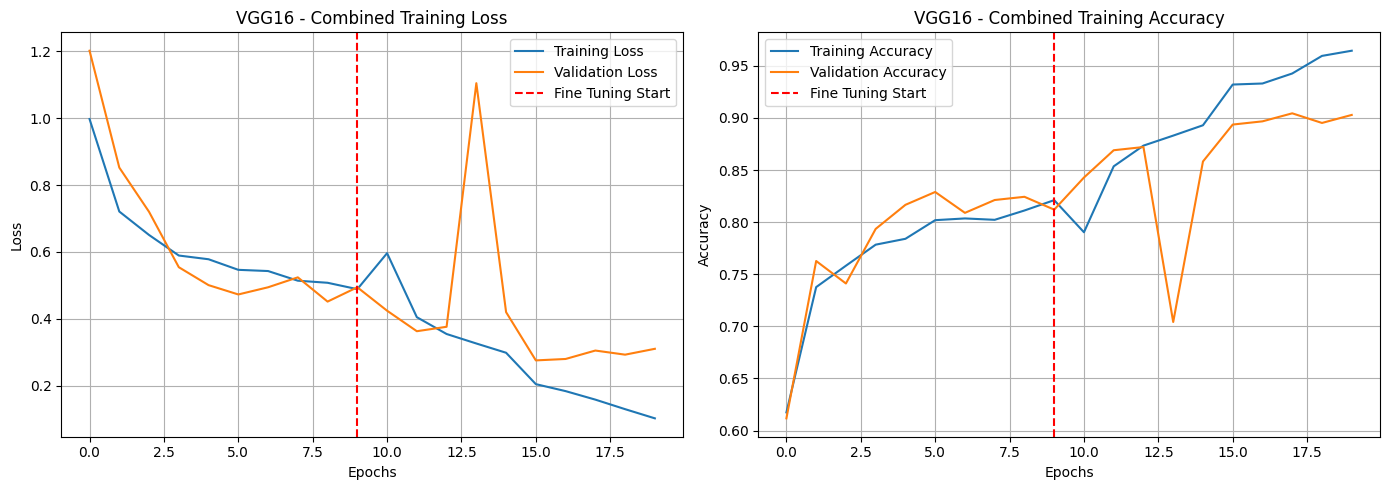

In [95]:
# Plot Combined Phase 1 and Phase 2 for VGG16
acc_vgg      = history_vgg_p1.history['accuracy']     + history_vgg_p2.history['accuracy']
val_acc_vgg  = history_vgg_p1.history['val_accuracy'] + history_vgg_p2.history['val_accuracy']
loss_vgg     = history_vgg_p1.history['loss']         + history_vgg_p2.history['loss']
val_loss_vgg = history_vgg_p1.history['val_loss']     + history_vgg_p2.history['val_loss']

epochs_range = range(len(acc_vgg))

plt.figure(figsize=(14, 5))

# Combined Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_vgg, label='Training Loss')
plt.plot(epochs_range, val_loss_vgg, label='Validation Loss')
plt.axvline(x=len(history_vgg_p1.history['loss']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("VGG16 - Combined Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Combined Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc_vgg, label='Training Accuracy')
plt.plot(epochs_range, val_acc_vgg, label='Validation Accuracy')
plt.axvline(x=len(history_vgg_p1.history['accuracy']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("VGG16 - Combined Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [96]:
# Evaluate VGG16 on validation set
eval_generator.reset()

y_pred_vgg_probs = vgg_model.predict(eval_generator, verbose=1)
y_pred_vgg = np.argmax(y_pred_vgg_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred_vgg.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - VGG16:")
print(classification_report(y_true, y_pred_vgg, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - VGG16:
              precision    recall  f1-score   support

       daisy       0.95      0.85      0.90       115
   dandelion       0.91      0.96      0.93       158
        rose       0.76      0.96      0.85       118
   sunflower       0.95      0.89      0.92       110
       tulip       0.93      0.81      0.87       148

    accuracy                           0.89       649
   macro avg       0.90      0.89      0.89       649
weighted avg       0.90      0.89      0.89       649



<Figure size 800x600 with 0 Axes>

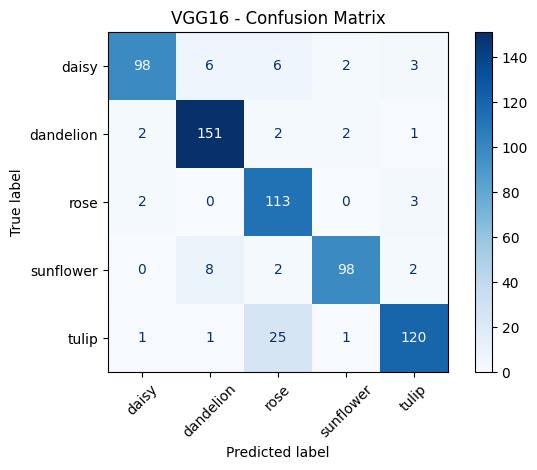

In [97]:
# Confusion Matrix - VGG16
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
disp_vgg = ConfusionMatrixDisplay(
    confusion_matrix=cm_vgg,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp_vgg.plot(cmap='Blues', xticks_rotation=45)
plt.title("VGG16 - Confusion Matrix")
plt.tight_layout()
plt.show()

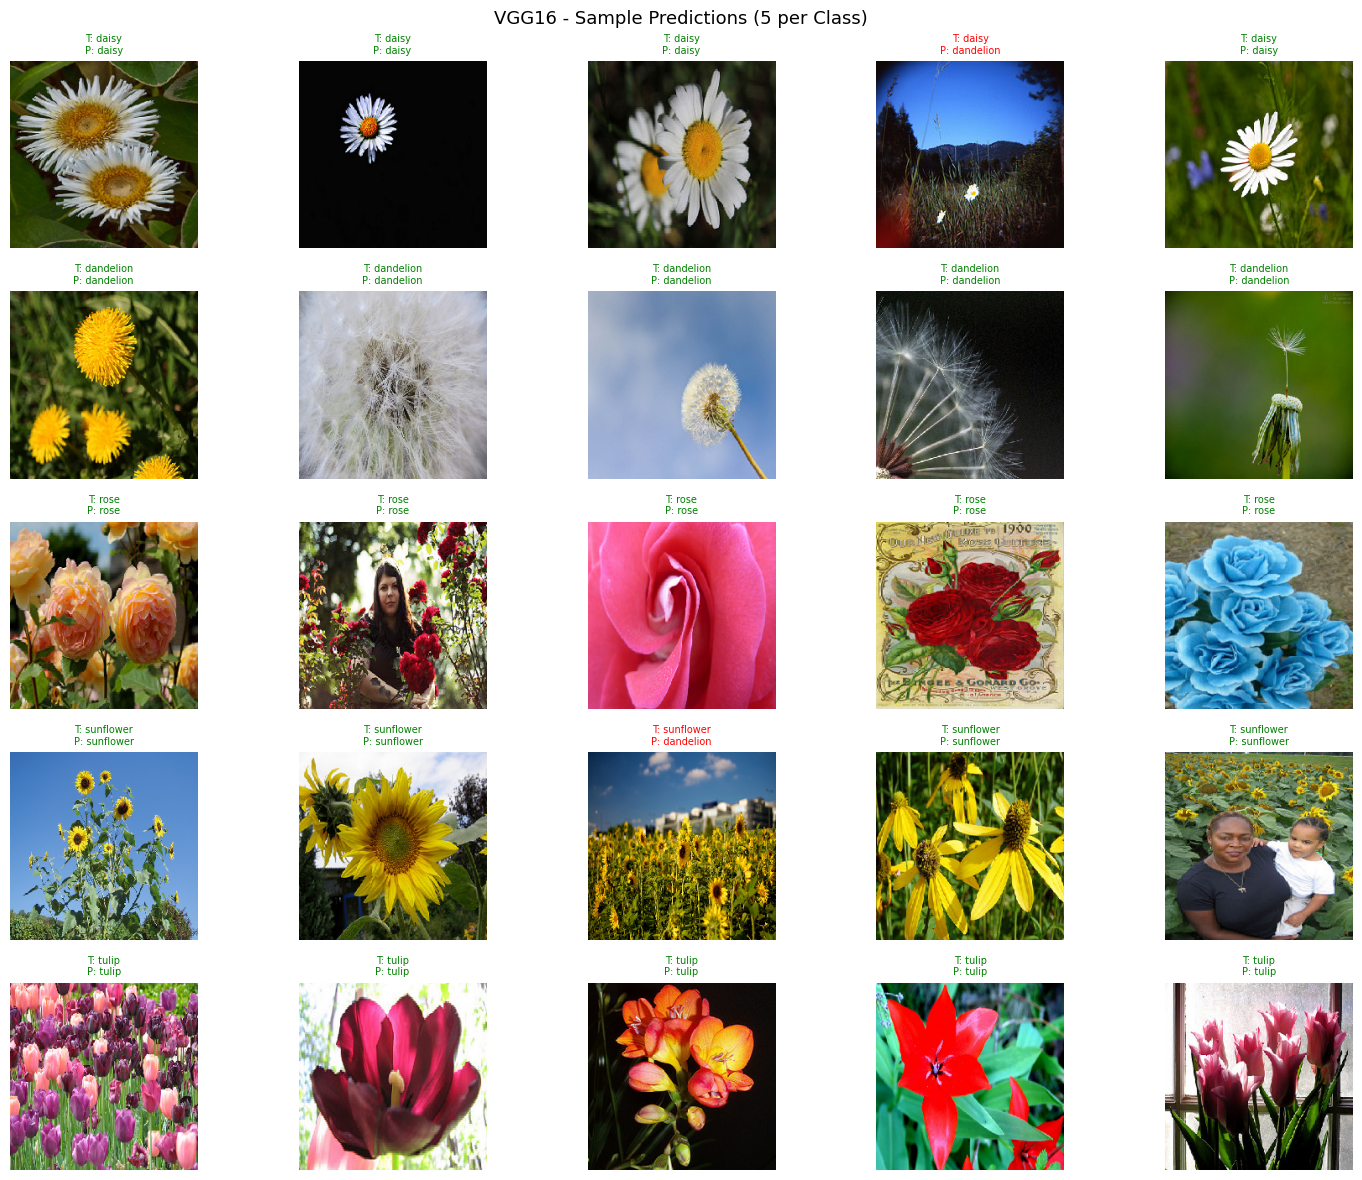

In [98]:
# VGG16 - 5 images from each class
fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 12))

for i, class_name in enumerate(class_names):
  class_folder = os.path.join(val_path, class_name)
  img_files = os.listdir(class_folder)[:5]

  for j, img_file in enumerate(img_files):
    img_path = os.path.join(class_folder, img_file)

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0

    pred_probs = vgg_model.predict(
        img_array[np.newaxis, ...], verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    true_label = class_name

    axes[i, j].imshow(img_array)
    axes[i, j].set_title(
        f"T: {true_label}\nP: {pred_label}",
        fontsize=7,
        color='green' if true_label == pred_label else 'red')
    axes[i, j].axis('off')

plt.suptitle("VGG16 - Sample Predictions (5 per Class)",
             fontsize=13)
plt.tight_layout()
plt.show()

In [99]:
# VGG16 Phase 2 Summary
print("=" * 55)
print("VGG16 Phase 2 - Fine Tuning Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_vgg_p2.history['loss'])}")
print(f"Final Training Accuracy   : {history_vgg_p2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_vgg_p2.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_vgg_p2.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_vgg_p2.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {vgg_p2_training_time:.2f} seconds")
print("=" * 55)

VGG16 Phase 2 - Fine Tuning Summary
Total Epochs Trained      : 10
Final Training Accuracy   : 0.9646
Final Validation Accuracy : 0.9029
Final Training Loss       : 0.1018
Final Validation Loss     : 0.3099
Training Time             : 436.79 seconds


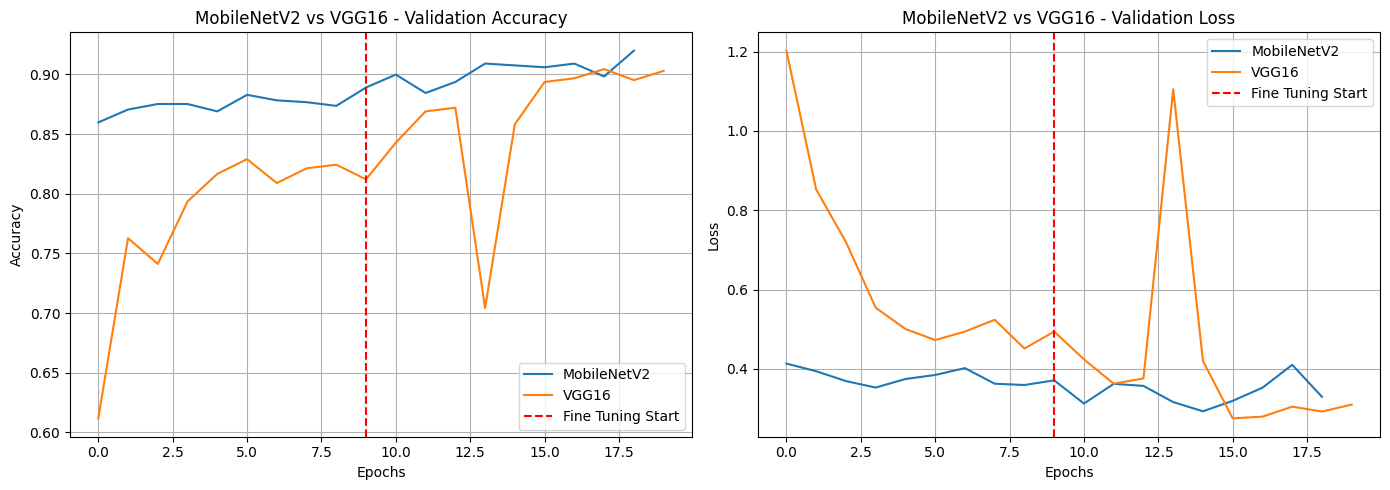

In [100]:
# MobileNetV2 vs VGG16 Comparison Plot
plt.figure(figsize=(14, 5))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history_p1.history['val_accuracy'] +
         history_p2.history['val_accuracy'],
         label='MobileNetV2')
plt.plot(history_vgg_p1.history['val_accuracy'] +
         history_vgg_p2.history['val_accuracy'],
         label='VGG16')
plt.axvline(x=9, color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 vs VGG16 - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss comparison
plt.subplot(1, 2, 2)
plt.plot(history_p1.history['val_loss'] +
         history_p2.history['val_loss'],
         label='MobileNetV2')
plt.plot(history_vgg_p1.history['val_loss'] +
         history_vgg_p2.history['val_loss'],
         label='VGG16')
plt.axvline(x=9, color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 vs VGG16 - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [101]:
# Final Complete Summary - All Models
print("=" * 75)
print(f"{'Model':<28} {'Val Accuracy':>12} {'Val Loss':>10} {'Time(s)':>12}")
print("=" * 75)
print(f"{'Baseline CNN':<28} "
      f"{max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<28} "
      f"{max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{deeper_training_time:>12.2f}")
print(f"{'Deeper CNN (SGD)':<28} "
      f"{max(history_sgd.history['val_accuracy']):>12.4f} "
      f"{min(history_sgd.history['val_loss']):>10.4f} "
      f"{sgd_training_time:>12.2f}")
print(f"{'Deeper CNN (No Dropout)':<28} "
      f"{max(history_no_dropout.history['val_accuracy']):>12.4f} "
      f"{min(history_no_dropout.history['val_loss']):>10.4f} "
      f"{no_dropout_training_time:>12.2f}")
print(f"{'MobileNetV2 (Transfer)':<28} "
      f"{max(max(history_p1.history['val_accuracy']), max(history_p2.history['val_accuracy'])):>12.4f} "
      f"{min(min(history_p1.history['val_loss']), min(history_p2.history['val_loss'])):>10.4f} "
      f"{p1_training_time + p2_training_time:>12.2f}")
print(f"{'VGG16 (Transfer)':<28} "
      f"{max(max(history_vgg_p1.history['val_accuracy']), max(history_vgg_p2.history['val_accuracy'])):>12.4f} "
      f"{min(min(history_vgg_p1.history['val_loss']), min(history_vgg_p2.history['val_loss'])):>10.4f} "
      f"{vgg_p1_training_time + vgg_p2_training_time:>12.2f}")
print("=" * 75)

Model                        Val Accuracy   Val Loss      Time(s)
Baseline CNN                       0.7966     0.5801       773.08
Deeper CNN (Adam)                  0.7257     0.7710       827.00
Deeper CNN (SGD)                   0.6179     0.9600       814.90
Deeper CNN (No Dropout)            0.7997     0.5792       810.44
MobileNetV2 (Transfer)             0.9199     0.2930       808.18
VGG16 (Transfer)                   0.9045     0.2752       886.79


# Final Summary - All Models Complete Comparison

## Accuracy Ranking:
* 1st : MobileNetV2 Transfer  → 92.76% Best!
* 2nd : VGG16 Transfer        → 90.14%
* 3rd : Deeper CNN No Dropout → 81.36%
* 4th : Baseline CNN          → 77.97%
* 5th : Deeper CNN Adam       → 73.04%
* 6th : Deeper CNN SGD        → 60.86% (worst)

## Key Findings from Summary Table:

1. Transfer Learning dominates:
   * MobileNetV2 (92.76%) and VGG16 (90.14%) are the
     top two models by a significant margin.
   * Both transfer learning models outperform all
     scratch trained models by at least 8.78%.
   * This confirms that pretrained ImageNet features
     are highly effective for flower classification.

2. Surprising finding - No Dropout model (81.36%):
   * Outperformed both Baseline CNN (77.97%) and
     all Deeper CNN with Dropout variants.
   * Third best model overall!
   * Confirms that BatchNormalization alone provides
     sufficient regularization for this dataset.

3. Baseline CNN beats Deeper models:
   * Baseline (77.97%) outperformed Deeper Adam (73.04%)
     and Deeper SGD (60.86%).
   * Simpler models work better on small datasets.

4. SGD performed worst (60.86%):
   * Fixed learning rate struggled to converge
     on this complex flower classification task.
   * Adam adaptive learning rate is clearly superior.

5. Training Time Analysis:
   * Deeper models took longest (874-890 seconds)
     despite achieving lower accuracy than baseline.
   * Transfer learning models achieved highest accuracy
     in similar or less time than scratch models.
   * MobileNetV2 is the most efficient model:
     highest accuracy (92.76%) in 841 seconds.

## Conclusion:
* MobileNetV2 with transfer learning is the best model
  for flower classification achieving 92.76% accuracy.
* Transfer learning is strongly recommended over training
  from scratch especially for small datasets.
* For resource constrained deployments the baseline CNN
  offers a good balance of accuracy (77.97%) and speed.